In [23]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 資料（已經分好訓練、內部驗證、外部驗證）匯入

In [1]:
import pandas as pd
# 讀取 Train70 工作表
train_set = pd.read_excel("PrediMOC_provide20250811_model1_grouped.xlsx", sheet_name='Train')
# 讀取 InternalTest30 工作表
internal_test_set = pd.read_excel("PrediMOC_provide20250811_model1_grouped.xlsx", sheet_name='InternalTest')

In [ ]:
train_set

In [ ]:
internal_test_set

In [2]:
# 讀取 ExternalTest 工作表
External_set = pd.read_excel("PrediMOC_provide20250811_model1_grouped", sheet_name='ExternalTest')

In [ ]:
External_set

In [5]:
# 統計並顯示各資料集中目標類別的筆數與比例
def show_class_distribution(df, name="Dataset"):
    counts = df['SMILoss4.2'].value_counts().sort_index()
    proportions = df['SMILoss4.2'].value_counts(normalize=True).sort_index() * 100
    summary = pd.DataFrame({
        'Label': counts.index,
        'Count': counts.values,
        'Proportion (%)': proportions.round(2).values
    })
    print(f"\n📊 {name} 分類分布:")
    print(summary.to_string(index=False))

# 顯示訓練集與測試集的分類比例
show_class_distribution(train_set, name="訓練集 (Train70%)")
show_class_distribution(internal_test_set, name="測試集 (Test30%)")
show_class_distribution(External_set, name="External_set ")


📊 訓練集 (Train70%) 分類分布:
 Label  Count  Proportion (%)
     0    299           74.75
     1    101           25.25

📊 測試集 (Test30%) 分類分布:
 Label  Count  Proportion (%)
     0    129            75.0
     1     43            25.0

📊 External_set  分類分布:
 Label  Count  Proportion (%)
     0    250           75.53
     1     81           24.47


In [6]:
# 定義特徵欄位（X）與標籤欄位（y）
feature_cols = [
    'Sex', 'Age', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy',
    'Smoking', 'pre_BMI', 'BMI_change', 'pre_SMI',
    'Dermatitis', 'Mucositis', 'Xerostomia', 'Dysphagia',
    'Pain', 'Anorexia', 'Nausea', 'Fatigue'
]
target_col = 'SMILoss4.2'

# 訓練集
X_train70 = train_set[feature_cols].copy()
y_train70 = train_set[target_col].copy()

# 測試集
X_test30 = internal_test_set[feature_cols].copy()
y_test30 = internal_test_set[target_col].copy()


In [7]:
# 外部驗證集
X_external = External_set[feature_cols].copy()
y_external = External_set[target_col].copy()
print("ExternalTest:", X_external.shape, y_external.shape)
assert list(X_external.columns) == feature_cols

ExternalTest: (331, 18) (331,)


# 模型 Bootstrap 函式

In [8]:
# 匯入所需套件
import numpy as np
import pandas as pd
import optuna

from tqdm.notebook import tqdm
from imblearn.over_sampling import SMOTENC
from optuna.samplers import TPESampler
# 匯入模型效能評估指標
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

GLOBAL_RANDOM_SEED = 42
# 定義資料中的連續型特徵欄位
continuous_cols = [
    "Age",
    "pre_BMI",
    "BMI_change",
    "pre_SMI",
]

In [9]:
def calculate_binary_metrics(y_true, y_prob, threshold=0.5):
    """統一計算三個模型的分類指標。"""
    # 依據指定閾值，將預測機率轉換為 0 或 1 的預測類別
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    # 計算並回傳各項模型效能指標
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "aucpr": average_precision_score(y_true, y_prob),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "sensitivity": recall_score(
            y_true,
            y_pred,
            pos_label=1,
            zero_division=0,
        ),
        "specificity": recall_score(
            y_true,
            y_pred,
            pos_label=0,
            zero_division=0,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
    }

In [10]:
# 建立 Bootstrap 驗證與 Optuna 超參數搜尋流程
def run_bootstrap_optuna(
    X,
    y,
    model_name,
    suggest_params,
    build_model,
    continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    threshold=0.5,
    global_seed=42,
):
    """
    流程：
    1. 有放回抽取 70%
    2. 未抽中樣本作為 OOB
    3. 重新排列連續與類別特徵
    4. Bootstrap training 執行 SMOTENC
    5. Optuna 根據 OOB AUC 選參數
    6. 使用最佳參數重新訓練
    7. 計算該輪 OOB 指標
    """

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    # 保存每輪評估結果及 OOB 預測資料
    bootstrap_results = []
    all_y_true = []
    all_y_prob = []
    all_y_id = []

    # 固定隨機種子
    np.random.seed(global_seed)

    for i in tqdm(
        range(n_bootstrap),
        desc=f"{model_name} Bootstrap Validation Progress",
    ):
        # 有放回抽取 70%的資料作為訓練集
        boot_indices = np.random.choice(
            len(X),
            size=int(sample_ratio * len(X)),
            replace=True,
        )

        # 將未被抽中的樣本作為 OOB 驗證集
        oob_indices = list(
            set(range(len(X))) - set(boot_indices)
        )

        print(
            f"[{i + 1}/{n_bootstrap}] "
            f"OOB samples: {len(oob_indices)}"
        )
        # 若 OOB 樣本數過少，跳過該輪以避免評估結果不穩定
        if len(oob_indices) < 0.1 * len(X):
            print(
                f"[Bootstrap {i}] skipped: "
                f"only {len(oob_indices)} OOB samples"
            )
            continue

        # Bootstrap training 與 OOB validation
        X_boot = X.iloc[boot_indices]
        y_boot = y.iloc[boot_indices]

        X_val = X.iloc[oob_indices]
        y_val = y.iloc[oob_indices]

        # 分離連續與類別特徵
        categorical_cols = [
            column
            for column in X.columns
            if column not in continuous_cols
        ]

        ordered_cols = (
            list(continuous_cols) +
            categorical_cols
        )

        # 保證 training、validation 欄位順序完全一致
        X_boot_scaled = (
            X_boot[ordered_cols].to_numpy()
        )

        X_val_scaled = (
            X_val[ordered_cols].to_numpy()
        )
       # 記錄類別型特徵的位置，供 SMOTENC 使用
        cat_features_idx = list(
            range(
                len(continuous_cols),
                len(ordered_cols),
            )
        )
        # 在第一次迭代時檢查特徵順序及特徵類型是否正確
        if i == 0:
            print("=== 第一次迭代檢查特徵排序 ===")

            for index, feature_name in enumerate(ordered_cols):
                feature_type = (
                    "Categorical"
                    if index in cat_features_idx
                    else "Continuous"
                )

                print(
                    f"Index {index:2d}: "
                    f"{feature_name:20s} "
                    f"<-- {feature_type}"
                )

        # SMOTENC 僅套用在 bootstrap training
        smote = SMOTENC(
            categorical_features=cat_features_idx,
            random_state=global_seed + i,
        )

        X_boot_res, y_boot_res = (
            smote.fit_resample(
                X_boot_scaled,
                y_boot,
            )
        )

        # Optuna objective，以 OOB AUC 評估每組超參數
        def objective(trial):
            # 取得當輪次所使用的超參數
            params = suggest_params(trial)
            # 依據指定參數建立並訓練模型
            model = build_model(
                params=params,
                iteration=i,
                tuning=True,
                global_seed=global_seed,
            )

            model.fit(
                X_boot_res,
                y_boot_res,
            )
            # 預測 OOB 樣本屬於正類別的機率
            y_prob = model.predict_proba(
                X_val_scaled
            )[:, 1]
            # 回傳 OOB AUC，作為 Optuna 的最佳化目標
            return roc_auc_score(
                y_val,
                y_prob,
            )
        # 建立 Optuna study，搜尋能使 OOB AUC 最大化的超參數
        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(
                seed=global_seed + i
            ),
        )

        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=False,
        )

        best_params = study.best_params

        # 使用該輪最佳參數重新訓練
        best_model = build_model(
            params=best_params,
            iteration=i,
            tuning=False,
            global_seed=global_seed,
        )

        best_model.fit(
            X_boot_res,
            y_boot_res,
        )
        # 取得最佳模型對 OOB 驗證集的預測機率
        y_prob = best_model.predict_proba(
            X_val_scaled
        )[:, 1]
        # 計算該輪 OOB 驗證的各項分類指標
        metrics = calculate_binary_metrics(
            y_true=y_val,
            y_prob=y_prob,
            threshold=threshold,
        )
        # 保存該輪模型名稱、評估指標及最佳超參數
        bootstrap_results.append({
            "model": model_name,
            **metrics,
            "params": best_params,
        })
        # 累積所有輪次的 OOB 真實標籤、預測機率及樣本索引
        all_y_true.extend(y_val.tolist())
        all_y_prob.extend(y_prob.tolist())
        all_y_id.extend(oob_indices)
        # 顯示該輪的模型評估結果
        print(
            f"[{model_name} Bootstrap {i}] "
            f"AUC: {metrics['auc']:.3f}, "
            f"AUCPR: {metrics['aucpr']:.3f}, "
            f"F1: {metrics['f1']:.3f}, "
            f"Acc: {metrics['accuracy']:.3f}, "
            f"Sen: {metrics['sensitivity']:.3f}, "
            f"Spe: {metrics['specificity']:.3f}, "
            f"Pre: {metrics['precision']:.3f}"
        )
        # 顯示目前成功完成的 Bootstrap 次數
        print(
            f"Total successful {model_name} bootstraps: "
            f"{len(bootstrap_results)}"
        )
    # 回傳各輪結果表及所有 OOB 預測資料
    return {
        "results": bootstrap_results,
        "results_df": pd.DataFrame(
            bootstrap_results
        ),
        "all_y_true": all_y_true,
        "all_y_prob": all_y_prob,
        "all_y_id": all_y_id,
    }

In [11]:
# 函式用於計算 Bootstrap 評估指標的平均值與 95% 信賴區間
def ci(series):
    # 移除缺失值
    clean_series = pd.Series(series).dropna()
    # 以第 2.5 與第 97.5 百分位數作為 95% 信賴區間的上下限
    return {
        "Mean": clean_series.mean(),
        "95% CI Lower": np.percentile(
            clean_series,
            2.5,
        ),
        "95% CI Upper": np.percentile(
            clean_series,
            97.5,
        ),
    }

In [12]:
# 彙整各項模型評估指標的平均值與 95% 信賴區間
def create_metrics_summary(results_df):
    # 設定表格顯示名稱及其對應的結果欄位
    metrics = {
        "AUC": "auc",
        "AUCPR": "aucpr",
        "F1-score": "f1",
        "Sensitivity": "sensitivity",
        "Specificity": "specificity",
        "Precision": "precision",
        "Accuracy": "accuracy",
    }
    # 算各項評估指標的平均值及 95% CI
    summary = pd.DataFrame({
        display_name: ci(results_df[column_name])
        for display_name, column_name in metrics.items()
    }).T

    return summary[
        [
            "Mean",
            "95% CI Lower",
            "95% CI Upper",
        ]
    ]

In [13]:
import os
import joblib
import pandas as pd

output_folder = "Model_1_Results_include"
os.makedirs(output_folder, exist_ok=True)


def save_bootstrap_output(
    output,
    model_prefix,
    output_folder,
):
    """
    保存 run_bootstrap_optuna() 回傳的結果。

    產生：
    1. Bootstrap 每輪指標與最佳參數 CSV
    2. 所有 OOB 預測 CSV
    3. 完整 Python 結構 joblib
    """
     # 定義輸出結果中必須包含的欄位
    required_keys = [
        "results",
        "results_df",
        "all_y_true",
        "all_y_prob",
        "all_y_id",
    ]
     # 檢查 Bootstrap 輸出
    missing_keys = [
        key
        for key in required_keys
        if key not in output
    ]

    if missing_keys:
        raise KeyError(
            f"{model_prefix} 缺少欄位："
            f"{missing_keys}"
        )

    # 確認三個 OOB list 長度一致
    prediction_lengths = {
        len(output["all_y_true"]),
        len(output["all_y_prob"]),
        len(output["all_y_id"]),
    }

    if len(prediction_lengths) != 1:
        raise ValueError(
            f"{model_prefix} 的 y_true、y_prob、"
            "Sample_Index 長度不一致"
        )

    # 取得各輪 Bootstrap 的評估結果
    results_df = output["results_df"].copy()

    if results_df.empty:
        raise ValueError(
            f"{model_prefix} 沒有 Bootstrap 結果"
        )
    # 將每輪的最佳超參數為獨立欄位
    params_df = (
        results_df["params"]
        .apply(pd.Series)
        .add_prefix("param_")
    )
    # 合併模型評估指標與最佳超參數
    detailed_logs = pd.concat(
        [
            results_df.drop(columns=["params"]),
            params_df,
        ],
        axis=1,
    )

    detailed_logs.index.name = (
        "Bootstrap_Result_Row"
    )
    # 儲存各輪 Bootstrap 指標與參數
    detailed_csv_path = os.path.join(
        output_folder,
        f"{model_prefix}_Bootstrap_Detailed_Logs.csv",
    )

    detailed_logs.to_csv(
        detailed_csv_path,
        index=True,
        encoding="utf-8-sig",
    )

    # 整理所有 Bootstrap 輪次中的 OOB 預測結果
    oob_predictions_df = pd.DataFrame({
        "Sample_Index": output["all_y_id"],
        "y_true": output["all_y_true"],
        "y_prob": output["all_y_prob"],
    })
    # 以 0.5 為閾值，將預測機率轉換為預測類別
    oob_predictions_df["y_pred"] = (
        oob_predictions_df["y_prob"] >= 0.5
    ).astype(int)
    # 將 OOB 預測結果儲存為 CSV
    oob_csv_path = os.path.join(
        output_folder,
        f"{model_prefix}_Bootstrap_OOB_Predictions.csv",
    )

    oob_predictions_df.to_csv(
        oob_csv_path,
        index=False,
        encoding="utf-8-sig",
    )

    # 使用 joblib 保存完整的 Bootstrap 輸出物件
    joblib_path = os.path.join(
        output_folder,
        f"{model_prefix}_Bootstrap_Complete_Output.joblib",
    )

    joblib.dump(
        output,
        joblib_path,
    )
    # 顯示各項結果的儲存位置
    print(f"✅ {model_prefix} 保存完成")
    print(f"指標與參數：{detailed_csv_path}")
    print(f"OOB 預測：{oob_csv_path}")
    print(f"完整結果：{joblib_path}")
    # 回傳詳細紀錄與 OOB 預測
    return detailed_logs, oob_predictions_df

# 選定最佳超參數、重訓練、驗證

In [14]:
# 選擇平均 AUC 最佳參數
def select_best_mean_auc_params(results_df,model_name=None):
    """
    將完整超參數組合相同的 bootstrap 結果分組，
    選擇平均 OOB AUC 最高的參數組合。
    """
    # 複製結果資料
    data = results_df.copy()
    # 若有指定模型名稱，僅保留該模型的 Bootstrap 結果
    if model_name is not None:
        data = data[data["model"] == model_name].copy()
   # 確認篩選後有可供分析的結果
    if data.empty:
        raise ValueError(
            f"找不到 {model_name} 的 bootstrap 結果"
        )
     # 定義選擇最佳參數時必須包含的欄位
    required_columns = {
        "params",
        "auc",
    }
    # 檢查結果中是否缺少必要欄位
    missing_columns = (
        required_columns -
        set(data.columns)
    )

    if missing_columns:
        raise ValueError(
            f"bootstrap 結果缺少欄位："
            f"{sorted(missing_columns)}"
        )

    # dict 轉為可分組、排序的 tuple
    data["param_key"] = data["params"].apply(
        lambda params: tuple(
            sorted(params.items())
        )
    )
    # 依照完整超參數組合分組，計算各組 AUC 的統計結果
    grouped = (
        data
        .groupby("param_key")
        .agg(
            mean_auc=("auc", "mean"),
            std_auc=("auc", "std"),
            count=("auc", "size"),
            min_auc=("auc", "min"),
            max_auc=("auc", "max"),
        )
        .reset_index()
    )

    # 將參數組合轉換為字串，作為結果相同時的固定排序依據
    grouped["param_sort_key"] = (
        grouped["param_key"].astype(str)
    )
    # 依序以平均 AUC、出現次數及參數字串決定最佳參數
    grouped = grouped.sort_values(
        by=[
            "mean_auc",
            "count",
            "param_sort_key",
        ],
        ascending=[
            False, # 優先選擇平均 AUC 較高者
            False, # 平均 AUC 相同時，選擇出現次數較多者
            True, # 前兩者皆相同時，以參數字串固定排序
        ],
        kind="mergesort",
    ).reset_index(drop=True)

    best_params = dict(
        grouped.loc[0, "param_key"]
    )
    # 回傳最佳參數及所有參數組合的統計結果
    return best_params, grouped

In [15]:
# 建立最終模型
def build_final_model(model_name,params,random_seed=42):
    # 建立 Random Forest 最終模型
    if model_name == "RandomForest":
        return RandomForestClassifier(
            **params,
            random_state=random_seed,
            n_jobs=-1,
        )
    # 建立 XGBoost 最終模型
    if model_name == "XGBoost":
        return XGBClassifier(
            **params,
            eval_metric="auc",
            random_state=random_seed,
            n_jobs=-1,
        )
    # 建立 CatBoost 最終模型
    if model_name == "CatBoost":
        return CatBoostClassifier(
            **params,
            random_seed=random_seed,
            verbose=0,
        )

    raise ValueError(
        f"不支援的模型：{model_name}"
    )

In [16]:
# 連續型特徵
continuous_cols = ["Age","pre_BMI","BMI_change","pre_SMI"]
# 全部特徵
feature_cols = [
    "Sex", "Age", "ECOG", "Tumor_site", "Stage",
    "Chemotherapy", "Smoking", "pre_BMI",
    "BMI_change", "pre_SMI", "Dermatitis",
    "Mucositis", "Xerostomia", "Dysphagia",
    "Pain", "Anorexia", "Nausea", "Fatigue"
]
# 將不屬於連續型特徵的欄位定義為類別型特徵
categorical_cols = [
    column
    for column in feature_cols
    if column not in continuous_cols
]

# 與 Bootstrap 訓練時完全相同：
# 連續特徵在前，類別特徵在後
feature_order = (
    continuous_cols +
    categorical_cols
)

print("特徵數量：", len(feature_order))
print("最終特徵順序：")
# 逐一顯示各特徵的位置及資料類型
for index, feature in enumerate(feature_order):
    feature_type = (
        "Continuous"
        if feature in continuous_cols
        else "Categorical"
    )

    print(
        f"{index:2d}. "
        f"{feature:20s} "
        f"{feature_type}"
    )

特徵數量： 18
最終特徵順序：
 0. Age                  Continuous
 1. pre_BMI              Continuous
 2. BMI_change           Continuous
 3. pre_SMI              Continuous
 4. Sex                  Categorical
 5. ECOG                 Categorical
 6. Tumor_site           Categorical
 7. Stage                Categorical
 8. Chemotherapy         Categorical
 9. Smoking              Categorical
10. Dermatitis           Categorical
11. Mucositis            Categorical
12. Xerostomia           Categorical
13. Dysphagia            Categorical
14. Pain                 Categorical
15. Anorexia             Categorical
16. Nausea               Categorical
17. Fatigue              Categorical


In [17]:
# 完整 Train70 重訓
def train_final_model(
    model_name,
    params,
    X_train,
    y_train,
    feature_order,
    continuous_cols,
    random_seed=42,
):
    """
    保留原流程：
    完整 Train70 → 固定欄位順序 → SMOTENC → 最終模型。
    """
    # 檢查訓練資料是否包含模型所需的全部特徵
    missing_columns = [
        column
        for column in feature_order
        if column not in X_train.columns
    ]

    if missing_columns:
        raise ValueError(
            f"Train70 缺少欄位："
            f"{missing_columns}"
        )
    # 依照 Bootstrap 階段的特徵順序排列資料，並轉換為陣列
    X_train_ordered = (
        X_train[
            feature_order
        ]
        .to_numpy()
    )
    # 取得類別型特徵在陣列中的位置
    categorical_indices = list(
        range(
            len(continuous_cols),
            len(feature_order),
        )
    )
    # 建立 SMOTENC
    smote = SMOTENC(
        categorical_features=(
            categorical_indices
        ),
        random_state=random_seed,
    )
    # 對完整 Train70 訓練資料進行過採樣
    X_train_resampled, y_train_resampled = (
        smote.fit_resample(
            X_train_ordered,
            y_train,
        )
    )
    # 使用選定的最佳超參數建立最終模型
    model = build_final_model(
        model_name=model_name,
        params=params,
        random_seed=random_seed,
    )
    # 使用經 SMOTENC 平衡後的資料訓練最終模型
    model.fit(
        X_train_resampled,
        y_train_resampled,
    )
    # 保存訓練流程的重要資訊
    training_information = {
        "original_sample_count": int(len(X_train_ordered)),
        "resampled_sample_count": int(len(X_train_resampled)),
        "feature_order": list(feature_order),
        "continuous_cols": list(continuous_cols),
        "categorical_indices": (categorical_indices),
        "random_seed": random_seed,
    }

    return model, training_information

In [18]:
# 內部驗證與外部驗證評估
def evaluate_final_model(model,X,y,feature_order,threshold=0.5):
    missing_columns = [
        column
        for column in feature_order
        if column not in X.columns
    ]
   # 檢查驗證資料是否包含模型所需的全部特徵
    if missing_columns:
        raise ValueError(
            f"評估資料缺少欄位："
            f"{missing_columns}"
        )
    # 按照模型訓練時的特徵順序排列驗證資料
    X_ordered = (
        X[
            feature_order
        ]
        .to_numpy()
    )
   # 將真實標籤轉換為 NumPy 陣列
    y_true = np.asarray(y)
    # 取得模型預測為正類別的機率
    y_prob = (
        model
        .predict_proba(X_ordered)[:, 1]
    )
    # 依照指定閾值，將預測機率轉換為預測類別
    y_pred = (
        y_prob >= threshold
    ).astype(int)
     # 計算驗證集的各項二元分類效能指標
    metrics = {
        "auc": float(roc_auc_score(y_true,y_prob,)),
        "aucpr": float(average_precision_score(y_true,y_prob,)),
        "f1": float(f1_score(y_true,y_pred,zero_division=0,)),
        "sensitivity": float(recall_score(y_true,y_pred,pos_label=1,zero_division=0,)),
        "specificity": float(recall_score(y_true,y_pred,pos_label=0,zero_division=0,)),
        "precision": float(precision_score(y_true,y_pred,zero_division=0,)),
        "accuracy": float(accuracy_score(y_true,y_pred,)),
    }
   # 整理每筆樣本的真實標籤、預測機率及預測類別
    predictions = pd.DataFrame({
        "Sample_Index": X.index,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    })
    # 回傳整體評估指標及個別樣本的預測結果
    return metrics, predictions

In [19]:
# 顯示指標
def print_metrics(
    model_name,
    dataset_name,
    metrics,
):
    # 顯示模型名稱及評估資料集名稱
    print(
        f"\n{model_name} - "
        f"{dataset_name}"
    )
    # 顯示各項二元分類效能指標，並保留至小數點後四位
    print(f"AUC:         {metrics['auc']:.4f}")
    print(f"AUCPR:       {metrics['aucpr']:.4f}")
    print(f"F1-score:    {metrics['f1']:.4f}")
    print(f"Sensitivity: "f"{metrics['sensitivity']:.4f}")
    print(f"Specificity: "f"{metrics['specificity']:.4f}")
    print(f"Precision:   "f"{metrics['precision']:.4f}")
    print(f"Accuracy:    "f"{metrics['accuracy']:.4f}")

In [20]:
#完整最終流程函式
def run_final_model_pipeline(model_name,bootstrap_output,X_train,y_train,X_internal,y_internal,X_external,y_external,
    feature_order,continuous_cols,output_folder,threshold=0.5,random_seed=42):
    """
    選參數、重訓、內部測試、外部驗證及存檔。
    """
    # 取得該模型各輪 Bootstrap 的評估結果
    results_df = (
        bootstrap_output["results_df"]
        .copy()
    )

    # 1. 選平均 OOB AUC 最佳參數
    best_params, grouped_params = (
        select_best_mean_auc_params(
            results_df=results_df,
            model_name=model_name,
        )
    )
    # 顯示最佳超參數
    print(
        f"\n{model_name} "
        "平均 OOB AUC 最佳參數："
    )

    print(best_params)
    # 顯示平均 OOB AUC 排名前十名的參數組合
    print("\n前 10 組參數：")

    display(
        grouped_params[
            [
                "mean_auc",
                "std_auc",
                "count",
                "min_auc",
                "max_auc",
                "param_key",
            ]
        ].head(10)
    )

    # 2. 完整 Train70 重訓
    final_model, training_information = (
        train_final_model(
            model_name=model_name,
            params=best_params,
            X_train=X_train,
            y_train=y_train,
            feature_order=feature_order,
            continuous_cols=continuous_cols,
            random_seed=random_seed,
        )
    )

    # 3. InternalTest
    internal_metrics, internal_predictions = (
        evaluate_final_model(
            model=final_model,
            X=X_internal,
            y=y_internal,
            feature_order=feature_order,
            threshold=threshold,
        )
    )

    # 4. ExternalTest
    external_metrics, external_predictions = (
        evaluate_final_model(
            model=final_model,
            X=X_external,
            y=y_external,
            feature_order=feature_order,
            threshold=threshold,
        )
    )

    print_metrics(
        model_name,
        "InternalTest",
        internal_metrics,
    )

    print_metrics(
        model_name,
        "ExternalTest",
        external_metrics,
    )

    # 5. 保存
    model_folder = os.path.join(output_folder,model_name,)
    os.makedirs(model_folder,exist_ok=True,)
    # 儲存訓練完成的最終模型
    joblib.dump(final_model,os.path.join(
            model_folder,f"{model_name}_Final_Model.joblib",),
    )
    # 儲存各超參數組合的 OOB AUC 統計結果
    grouped_params.assign(
        param_key=grouped_params[
            "param_key"
        ].astype(str)
    ).to_csv(
        os.path.join(
            model_folder,
            f"{model_name}_Parameter_Groups.csv",
        ),
        index=False,
        encoding="utf-8-sig",
    )
    # 儲存內部測試集的個別樣本預測結果
    internal_predictions.to_csv(
        os.path.join(
            model_folder,
            f"{model_name}_Internal_Predictions.csv",
        ),
        index=False,
        encoding="utf-8-sig",
    )
    # 儲存外部驗證集的個別樣本預測結果
    external_predictions.to_csv(
        os.path.join(
            model_folder,
            f"{model_name}_External_Predictions.csv",
        ),
        index=False,
        encoding="utf-8-sig",
    )
    # 整理本次模型執行的重要設定與評估結果
    run_information = {
        "model_name": model_name,
        "selected_params": best_params,
        "selection_rule": (
            "Highest mean OOB AUC for an "
            "identical complete parameter combination"
        ),
        "feature_order": list(
            feature_order
        ),
        "continuous_cols": list(
            continuous_cols
        ),
        "threshold": threshold,
        "random_seed": random_seed,
        "training_information": (
            training_information
        ),
        "internal_metrics": (
            internal_metrics
        ),
        "external_metrics": (
            external_metrics
        ),
    }

    with open(
        os.path.join(
            model_folder,
            f"{model_name}_Run_Information.json",
        ),
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            run_information,
            file,
            ensure_ascii=False,
            indent=2,
        )

    # joblib 可完整保留 Python 型別
    joblib.dump(
        run_information,
        os.path.join(
            model_folder,
            f"{model_name}_Run_Information.joblib",
        ),
    )
    # 回傳模型、最佳參數、訓練資訊及內外部驗證結果
    return {
        "model": final_model,
        "best_params": best_params,
        "grouped_params": grouped_params,
        "training_information": (training_information),
        "internal_metrics": (internal_metrics),
        "internal_predictions": (internal_predictions),
        "external_metrics": (external_metrics),
        "external_predictions": (external_predictions),
    }

# RF boostrap

In [31]:
# 定義 Random Forest 的超參數搜尋範圍
def suggest_rf_params(trial):
    return {
        # 決策樹的數量
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        # 每棵決策樹的最大深度
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        # 節點繼續分裂所需的最少樣本數
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        # 葉節點所需的最少樣本數
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        # 每次節點分裂時考慮的特徵數量
        "max_features": trial.suggest_categorical("max_features",["sqrt", "log2"]),
    }

# 定義 Random Forest 模型的建立
def build_rf(
    params,
    iteration,
    tuning,
    global_seed,
):
    return RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1,
    )

In [32]:
# 執行 Bootstrap 驗證與 Optuna 超參數搜尋
rf_output = run_bootstrap_optuna(
    X=X_train70,
    y=y_train70,
    model_name="RandomForest",
    suggest_params=suggest_rf_params,
    build_model=build_rf,
    continuous_cols=continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    global_seed=42,
)

RandomForest Bootstrap Validation Progress:   0%|          | 0/500 [00:00<?, ?it/s]

[1/500] OOB samples: 207
=== 第一次迭代檢查特徵排序 ===
Index  0: Age                  <-- Continuous
Index  1: pre_BMI              <-- Continuous
Index  2: BMI_change           <-- Continuous
Index  3: pre_SMI              <-- Continuous
Index  4: Sex                  <-- Categorical
Index  5: ECOG                 <-- Categorical
Index  6: Tumor_site           <-- Categorical
Index  7: Stage                <-- Categorical
Index  8: Chemotherapy         <-- Categorical
Index  9: Smoking              <-- Categorical
Index 10: Dermatitis           <-- Categorical
Index 11: Mucositis            <-- Categorical
Index 12: Xerostomia           <-- Categorical
Index 13: Dysphagia            <-- Categorical
Index 14: Pain                 <-- Categorical
Index 15: Anorexia             <-- Categorical
Index 16: Nausea               <-- Categorical
Index 17: Fatigue              <-- Categorical
[RandomForest Bootstrap 0] AUC: 0.936, AUCPR: 0.870, F1: 0.752, Acc: 0.879, Sen: 0.704, Spe: 0.941, Pre: 0.809
To

In [35]:
# 儲存 Random Forest 的各輪 Bootstrap 結果、OOB 預測及完整輸出物件
rf_detailed_logs, rf_oob_predictions = (
    save_bootstrap_output(
        output=rf_output,
        model_prefix="RF",
        output_folder="Model_1_Results_include",
    )
)

✅ RF 保存完成
指標與參數：Model_1_Results_include/RF_Bootstrap_Detailed_Logs.csv
OOB 預測：Model_1_Results_include/RF_Bootstrap_OOB_Predictions.csv
完整結果：Model_1_Results_include/RF_Bootstrap_Complete_Output.joblib


In [36]:
# 取得各輪 Bootstrap 結果
bootstrap_results = rf_output["results"]
results_df = rf_output["results_df"]
# 取得所有 OOB 樣本的真實標籤、預測機率及原始樣本索引
all_y_true = rf_output["all_y_true"]
all_y_prob = rf_output["all_y_prob"]
rf_all_y_id = rf_output["all_y_id"]
# 彙整各項評估指標的平均值與 95% 信賴區間
metrics_summary = create_metrics_summary(
    results_df
)

display(metrics_summary)

,Mean,95% CI Lower,95% CI Upper
AUC,0.941734,0.914170,0.969342
AUCPR,0.863575,0.792027,0.921549
F1-score,0.785049,0.693862,0.860000
Sensitivity,0.753823,0.597352,0.892519
Specificity,0.945612,0.900995,0.979310
Precision,0.826183,0.722784,0.913696
Accuracy,0.896855,0.860444,0.929293


# RF 選擇最佳超參數、使用完整 Train70 重訓、進行內外部驗證

In [29]:
import json

In [37]:
rf_final_output = run_final_model_pipeline(
    model_name="RandomForest",
    bootstrap_output=rf_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    feature_order=feature_order,
    continuous_cols=continuous_cols,
    output_folder="Model_1_Results_include",
    threshold=0.5,
    random_seed=42,
)


RandomForest 平均 OOB AUC 最佳參數：
{'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 9, 'n_estimators': 77}

前 10 組參數：


,mean_auc,std_auc,count,min_auc,max_auc,param_key
0,0.978779,NaN,1,0.978779,0.978779,"((max_depth, 3), (max_features, sqrt), (min_sa..."
1,0.978301,NaN,1,0.978301,0.978301,"((max_depth, 20), (max_features, log2), (min_s..."
2,0.975000,NaN,1,0.975000,0.975000,"((max_depth, 3), (max_features, sqrt), (min_sa..."
3,0.973874,NaN,1,0.973874,0.973874,"((max_depth, 13), (max_features, log2), (min_s..."
4,0.972117,NaN,1,0.972117,0.972117,"((max_depth, 13), (max_features, log2), (min_s..."
5,0.971282,NaN,1,0.971282,0.971282,"((max_depth, 4), (max_features, sqrt), (min_sa..."
6,0.971280,NaN,1,0.971280,0.971280,"((max_depth, 5), (max_features, log2), (min_sa..."
7,0.971190,NaN,1,0.971190,0.971190,"((max_depth, 13), (max_features, sqrt), (min_s..."
8,0.970922,NaN,1,0.970922,0.970922,"((max_depth, 5), (max_features, sqrt), (min_sa..."
9,0.970047,NaN,1,0.970047,0.970047,"((max_depth, 3), (max_features, sqrt), (min_sa..."



RandomForest - InternalTest
AUC:         0.9677
AUCPR:       0.9287
F1-score:    0.8780
Sensitivity: 0.8372
Specificity: 0.9767
Precision:   0.9231
Accuracy:    0.9419

RandomForest - ExternalTest
AUC:         0.9858
AUCPR:       0.9572
F1-score:    0.8662
Sensitivity: 0.8395
Specificity: 0.9680
Precision:   0.8947
Accuracy:    0.9366


# XGB boostrap

In [24]:
# 定義 XGBoost 的超參數搜尋範圍
def suggest_xgb_params(trial):
    return {
        # 每棵決策樹的最大深度
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        # 子節點繼續分裂所需的最小權重
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        # 控制節點分裂所需的最低損失改善程度
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        # 每棵樹訓練時使用的樣本比例
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        # 每棵樹訓練時使用的特徵比例
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # 模型每次更新的學習步幅
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.2,log=True,),
        # L1 正則化強度
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        # L2 正則化強度
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        # 模型使用的決策樹數量
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
    }

# 定義 XGBoost 模型的建立
def build_xgb(
    params,
    iteration,
    tuning,
    global_seed,
):
    if tuning:
        # 保留原 objective 的設定
        return XGBClassifier(
            **params,
            eval_metric="auc",
        )

    # 保留原本最佳模型的設定
    return XGBClassifier(
        **params,
        eval_metric="auc",
        random_state=global_seed + iteration,
        n_jobs=-1,
        verbosity=0,
    )

In [25]:
# Bootstrap 驗證與 Optuna 超參數搜尋
xgb_output = run_bootstrap_optuna(
    X=X_train70,
    y=y_train70,
    model_name="XGBoost",
    suggest_params=suggest_xgb_params,
    build_model=build_xgb,
    continuous_cols=continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    global_seed=42,
)

XGBoost Bootstrap Validation Progress:   0%|          | 0/500 [00:00<?, ?it/s]

[1/500] OOB samples: 207
=== 第一次迭代檢查特徵排序 ===
Index  0: Age                  <-- Continuous
Index  1: pre_BMI              <-- Continuous
Index  2: BMI_change           <-- Continuous
Index  3: pre_SMI              <-- Continuous
Index  4: Sex                  <-- Categorical
Index  5: ECOG                 <-- Categorical
Index  6: Tumor_site           <-- Categorical
Index  7: Stage                <-- Categorical
Index  8: Chemotherapy         <-- Categorical
Index  9: Smoking              <-- Categorical
Index 10: Dermatitis           <-- Categorical
Index 11: Mucositis            <-- Categorical
Index 12: Xerostomia           <-- Categorical
Index 13: Dysphagia            <-- Categorical
Index 14: Pain                 <-- Categorical
Index 15: Anorexia             <-- Categorical
Index 16: Nausea               <-- Categorical
Index 17: Fatigue              <-- Categorical
[XGBoost Bootstrap 0] AUC: 0.923, AUCPR: 0.843, F1: 0.738, Acc: 0.870, Sen: 0.704, Spe: 0.928, Pre: 0.776
Total s

In [26]:
# 儲存各輪 Bootstrap 結果、OOB 預測及完整輸出物件
xgb_detailed_logs, xgb_oob_predictions = (
    save_bootstrap_output(
        output=xgb_output,
        model_prefix="XGB",
        output_folder="Model_1_Results_include",
    )
)

display(xgb_detailed_logs.head())
display(xgb_oob_predictions.head())

✅ XGB 保存完成
指標與參數：Model_1_Results_include/XGB_Bootstrap_Detailed_Logs.csv
OOB 預測：Model_1_Results_include/XGB_Bootstrap_OOB_Predictions.csv
完整結果：Model_1_Results_include/XGB_Bootstrap_Complete_Output.joblib


,model,auc,aucpr,f1,sensitivity,specificity,precision,accuracy,param_max_depth,param_min_child_weight,param_gamma,param_subsample,param_colsample_bytree,param_learning_rate,param_reg_alpha,param_reg_lambda,param_n_estimators
Bootstrap_Result_Row,,,,,,,,,,,,,,,,,
0,XGBoost,0.922718,0.843235,0.737864,0.703704,0.928105,0.775510,0.869565,6.0,3.0,0.514648,0.994178,0.842674,0.157756,1.543848,3.330292,265.0
1,XGBoost,0.943756,0.894021,0.860000,0.843137,0.960526,0.877551,0.931034,5.0,5.0,0.896788,0.771223,0.670303,0.035767,1.537791,3.841945,167.0
2,XGBoost,0.946682,0.888631,0.790698,0.790698,0.945122,0.790698,0.913043,4.0,9.0,0.431803,0.966229,0.776737,0.030452,0.981991,0.598892,147.0
3,XGBoost,0.942329,0.883631,0.821429,0.920000,0.890411,0.741935,0.897959,5.0,7.0,0.680971,0.855004,0.603605,0.058394,1.600887,2.736166,400.0
4,XGBoost,0.931347,0.806044,0.641975,0.604651,0.928144,0.684211,0.861905,4.0,2.0,0.195127,0.731967,0.808316,0.010189,1.581210,0.693555,153.0


,Sample_Index,y_true,y_prob,y_pred
0,0,0,0.281755,0
1,2,0,0.048324,0
2,3,0,0.008842,0
3,5,0,0.023620,0
4,6,0,0.022072,0


In [27]:
# 從取得各輪 Bootstrap 結果
xgb_bootstrap_results = xgb_output["results"]
xgb_results_df = xgb_output["results_df"]
# 取得所有 OOB 樣本的真實標籤、預測機率及原始樣本索引
xgb_all_y_true = xgb_output["all_y_true"]
xgb_all_y_prob = xgb_output["all_y_prob"]
xgb_all_y_id = xgb_output["all_y_id"]
# 彙整各項模型評估指標的平均值與 95% 信賴區間
xgb_metrics_summary = create_metrics_summary(
    xgb_results_df
)

display(xgb_metrics_summary)

,Mean,95% CI Lower,95% CI Upper
AUC,0.939004,0.908344,0.969081
AUCPR,0.867663,0.801546,0.924808
F1-score,0.795612,0.715913,0.857143
Sensitivity,0.795701,0.641767,0.916667
Specificity,0.932374,0.879577,0.971743
Precision,0.801413,0.690251,0.895312
Accuracy,0.897757,0.865469,0.927657


# XGB 選擇最佳超參數、使用完整 Train70 重訓、進行內外部驗證

In [30]:
xgb_final_output = run_final_model_pipeline(
    model_name="XGBoost",
    bootstrap_output=xgb_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    feature_order=feature_order,
    continuous_cols=continuous_cols,
    output_folder="Model_1_Results_include",
    threshold=0.5,
    random_seed=42,
)


XGBoost 平均 OOB AUC 最佳參數：
{'colsample_bytree': 0.6409347039284274, 'gamma': 0.9223974748144249, 'learning_rate': 0.013486020311323559, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 238, 'reg_alpha': 0.19285220073324372, 'reg_lambda': 3.4805334895560858, 'subsample': 0.8608949288742551}

前 10 組參數：


,mean_auc,std_auc,count,min_auc,max_auc,param_key
0,0.982267,NaN,1,0.982267,0.982267,"((colsample_bytree, 0.6409347039284274), (gamm..."
1,0.978340,NaN,1,0.978340,0.978340,"((colsample_bytree, 0.6655376153220433), (gamm..."
2,0.976740,NaN,1,0.976740,0.976740,"((colsample_bytree, 0.7499462536134618), (gamm..."
3,0.975294,NaN,1,0.975294,0.975294,"((colsample_bytree, 0.6427893056844244), (gamm..."
4,0.974043,NaN,1,0.974043,0.974043,"((colsample_bytree, 0.9726061467857587), (gamm..."
5,0.973377,NaN,1,0.973377,0.973377,"((colsample_bytree, 0.8528221373717075), (gamm..."
6,0.971923,NaN,1,0.971923,0.971923,"((colsample_bytree, 0.6661906109251793), (gamm..."
7,0.970865,NaN,1,0.970865,0.970865,"((colsample_bytree, 0.9937823146665741), (gamm..."
8,0.970721,NaN,1,0.970721,0.970721,"((colsample_bytree, 0.7024856488353096), (gamm..."
9,0.970266,NaN,1,0.970266,0.970266,"((colsample_bytree, 0.6370741661340129), (gamm..."



XGBoost - InternalTest
AUC:         0.9638
AUCPR:       0.9272
F1-score:    0.8354
Sensitivity: 0.7674
Specificity: 0.9767
Precision:   0.9167
Accuracy:    0.9244

XGBoost - ExternalTest
AUC:         0.9905
AUCPR:       0.9643
F1-score:    0.9091
Sensitivity: 0.9259
Specificity: 0.9640
Precision:   0.8929
Accuracy:    0.9547


# Catboost boostrap

In [63]:
# 定義 CatBoost 的超參數搜尋範圍
def suggest_cat_params(trial):
    return {
        # 模型進行迭代訓練的次數
        "iterations": trial.suggest_int("iterations", 100, 600),
        # 模型每次更新的學習步幅
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.2,log=True,),
        # 每棵決策樹的最大深度
        "depth": trial.suggest_int("depth", 3, 8),
        # L2 正則化強度
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        # 控制 Bootstrap 抽樣的隨機程度
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        # 連續型特徵離散化時使用的區間數量
        "border_count": trial.suggest_int("border_count", 32, 255),
        # 控制節點分裂評分的隨機程度
        "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
        # 每次建立決策樹時使用的特徵比例
        "rsm": trial.suggest_float("rsm", 0.6, 1.0),
        # 決定是否依照類別分布自動調整類別權重
        "auto_class_weights": trial.suggest_categorical("auto_class_weights",[None, "Balanced"],),
    }

# 定義 CatBoost 模型
def build_catboost(
    params,
    iteration,
    tuning,
    global_seed,
):
    if tuning:
        return CatBoostClassifier(
            **params,
            random_seed=42,
            verbose=0,
        )

    return CatBoostClassifier(
        **params,
        random_seed=global_seed + iteration,
        verbose=0,
    )

In [64]:
# 執行 Bootstrap 驗證與 Optuna 超參數搜尋
cat_output = run_bootstrap_optuna(
    X=X_train70,
    y=y_train70,
    model_name="CatBoost",
    suggest_params=suggest_cat_params,
    build_model=build_catboost,
    continuous_cols=continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    global_seed=42,
)

CatBoost Bootstrap Validation Progress:   0%|          | 0/500 [00:00<?, ?it/s]

[1/500] OOB samples: 207
=== 第一次迭代檢查特徵排序 ===
Index  0: Age                  <-- Continuous
Index  1: pre_BMI              <-- Continuous
Index  2: BMI_change           <-- Continuous
Index  3: pre_SMI              <-- Continuous
Index  4: Sex                  <-- Categorical
Index  5: ECOG                 <-- Categorical
Index  6: Tumor_site           <-- Categorical
Index  7: Stage                <-- Categorical
Index  8: Chemotherapy         <-- Categorical
Index  9: Smoking              <-- Categorical
Index 10: Dermatitis           <-- Categorical
Index 11: Mucositis            <-- Categorical
Index 12: Xerostomia           <-- Categorical
Index 13: Dysphagia            <-- Categorical
Index 14: Pain                 <-- Categorical
Index 15: Anorexia             <-- Categorical
Index 16: Nausea               <-- Categorical
Index 17: Fatigue              <-- Categorical
[CatBoost Bootstrap 0] AUC: 0.936, AUCPR: 0.836, F1: 0.765, Acc: 0.884, Sen: 0.722, Spe: 0.941, Pre: 0.812
Total 

In [65]:
# 儲存各輪 Bootstrap 結果、OOB 預測及完整輸出物件
cat_detailed_logs, cat_oob_predictions = (
    save_bootstrap_output(
        output=cat_output,
        model_prefix="CatBoost",
        output_folder="Model_1_Results_include",
    )
)
display(cat_detailed_logs.head())
display(cat_oob_predictions.head())

✅ CatBoost 保存完成
指標與參數：Model_1_Results_include/CatBoost_Bootstrap_Detailed_Logs.csv
OOB 預測：Model_1_Results_include/CatBoost_Bootstrap_OOB_Predictions.csv
完整結果：Model_1_Results_include/CatBoost_Bootstrap_Complete_Output.joblib


,model,auc,aucpr,f1,sensitivity,specificity,precision,accuracy,param_iterations,param_learning_rate,param_depth,param_l2_leaf_reg,param_bagging_temperature,param_border_count,param_random_strength,param_rsm,param_auto_class_weights
Bootstrap_Result_Row,,,,,,,,,,,,,,,,,
0,CatBoost,0.936214,0.835881,0.764706,0.722222,0.941176,0.812500,0.884058,532.0,0.064704,4.0,1.572025,0.310982,104.0,0.729606,0.855023,NaN
1,CatBoost,0.949561,0.891578,0.860000,0.843137,0.960526,0.877551,0.931034,222.0,0.010415,3.0,1.694309,0.430100,46.0,0.804026,0.853417,Balanced
2,CatBoost,0.951929,0.868886,0.786517,0.813953,0.932927,0.760870,0.908213,254.0,0.035408,4.0,6.112678,0.095285,210.0,0.268656,0.964566,NaN
3,CatBoost,0.948630,0.862705,0.822430,0.880000,0.910959,0.771930,0.903061,467.0,0.027448,7.0,3.925422,0.138485,212.0,0.670339,0.619648,NaN
4,CatBoost,0.931904,0.787056,0.735632,0.744186,0.928144,0.727273,0.890476,163.0,0.076091,5.0,3.357900,0.189416,67.0,0.700621,0.832627,Balanced


,Sample_Index,y_true,y_prob,y_pred
0,0,0,0.010880,0
1,2,0,0.001758,0
2,3,0,0.000013,0
3,5,0,0.003940,0
4,6,0,0.000262,0


In [66]:
# 取得各輪 Bootstrap 結果
cat_bootstrap_results = cat_output["results"]
cat_results_df = cat_output["results_df"]
# 取得所有 OOB 樣本的真實標籤、預測機率及原始樣本索引
cat_all_y_true = cat_output["all_y_true"]
cat_all_y_prob = cat_output["all_y_prob"]
cat_all_y_id = cat_output["all_y_id"]
# 彙整各項評估指標的平均值與 95% 信賴區間
cat_metrics_summary = create_metrics_summary(
    cat_results_df
)

display(cat_metrics_summary)

,Mean,95% CI Lower,95% CI Upper
AUC,0.941842,0.910747,0.971117
AUCPR,0.868720,0.796688,0.925907
F1-score,0.793758,0.717363,0.860113
Sensitivity,0.787418,0.638795,0.907461
Specificity,0.935166,0.888797,0.972323
Precision,0.806136,0.708063,0.896675
Accuracy,0.897717,0.865672,0.930693


# Catboost 選擇最佳超參數、使用完整 Train70 重訓、進行內外部驗證

In [38]:
cat_final_output = run_final_model_pipeline(
    model_name="CatBoost",
    bootstrap_output=cat_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    feature_order=feature_order,
    continuous_cols=continuous_cols,
    output_folder="Model_1_Results_include",
    threshold=0.5,
    random_seed=42,
)


CatBoost 平均 OOB AUC 最佳參數：
{'auto_class_weights': 'Balanced', 'bagging_temperature': 0.29257907007976447, 'border_count': 126, 'depth': 4, 'iterations': 143, 'l2_leaf_reg': 2.487359219625439, 'learning_rate': 0.04068169642603104, 'random_strength': 0.47604396533671933, 'rsm': 0.7410103534684758}

前 10 組參數：


,mean_auc,std_auc,count,min_auc,max_auc,param_key
0,0.977907,NaN,1,0.977907,0.977907,"((auto_class_weights, Balanced), (bagging_temp..."
1,0.977447,NaN,1,0.977447,0.977447,"((auto_class_weights, Balanced), (bagging_temp..."
2,0.976358,NaN,1,0.976358,0.976358,"((auto_class_weights, Balanced), (bagging_temp..."
3,0.976209,NaN,1,0.976209,0.976209,"((auto_class_weights, None), (bagging_temperat..."
4,0.975740,NaN,1,0.975740,0.975740,"((auto_class_weights, None), (bagging_temperat..."
5,0.975736,NaN,1,0.975736,0.975736,"((auto_class_weights, None), (bagging_temperat..."
6,0.972879,NaN,1,0.972879,0.972879,"((auto_class_weights, None), (bagging_temperat..."
7,0.972808,NaN,1,0.972808,0.972808,"((auto_class_weights, Balanced), (bagging_temp..."
8,0.972024,NaN,1,0.972024,0.972024,"((auto_class_weights, None), (bagging_temperat..."
9,0.971920,NaN,1,0.971920,0.971920,"((auto_class_weights, Balanced), (bagging_temp..."



CatBoost - InternalTest
AUC:         0.9571
AUCPR:       0.9228
F1-score:    0.8395
Sensitivity: 0.7907
Specificity: 0.9690
Precision:   0.8947
Accuracy:    0.9244

CatBoost - ExternalTest
AUC:         0.9903
AUCPR:       0.9655
F1-score:    0.9091
Sensitivity: 0.9259
Specificity: 0.9640
Precision:   0.8929
Accuracy:    0.9547


# ROC-AUC, PR-AUC繪圖

In [82]:
# 匯入資料處理、統計分析、繪圖及模型評估所需套件
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score, accuracy_score
)
# 整理三個模型在 Bootstrap 驗證中的真實標籤、預測機率及各輪評估結果
bootstrap_data = {
    "RF": {
        "y_true": np.asarray(rf_output["all_y_true"]),
        "y_prob": np.asarray(rf_output["all_y_prob"]),
        "results": rf_output["results_df"],
    },
    "XGBoost": {
        "y_true": np.asarray(xgb_output["all_y_true"]),
        "y_prob": np.asarray(xgb_output["all_y_prob"]),
        "results": xgb_output["results_df"],
    },
    "CatBoost": {
        "y_true": np.asarray(cat_output["all_y_true"]),
        "y_prob": np.asarray(cat_output["all_y_prob"]),
        "results": cat_output["results_df"],
    },
}
# 整理三個模型在內部測試集上的預測結果
internal_data = {
    "RF": rf_final_output["internal_predictions"],
    "XGBoost": xgb_final_output["internal_predictions"],
    "CatBoost": cat_final_output["internal_predictions"],
}
# 整理三個模型在外部驗證集上的預測結果
external_data = {
    "RF": rf_final_output["external_predictions"],
    "XGBoost": xgb_final_output["external_predictions"],
    "CatBoost": cat_final_output["external_predictions"],
}

In [83]:
# 定義函式，計算評估指標的平均值與 95% 信賴區間
def ci(series):
    series = pd.Series(series)
    return {
        "mean": series.mean(),
        "lower": np.percentile(series, 2.5),
        "upper": np.percentile(series, 97.5),
    }

In [84]:
# 繪製三個模型的 Bootstrap ROC 曲線
def plot_bootstrap_roc(bootstrap_data, title="Average ROC Curve Based on Bootstrap"):
    # 建立 ROC 圖表
    plt.figure(figsize=(8, 6))
    # 分別計算並繪製各模型的 ROC 曲線
    for model_name, data in bootstrap_data.items():
        # 使用彙整後的 OOB 預測結果計算 ROC 曲線
        fpr, tpr, _ = roc_curve(data["y_true"], data["y_prob"])
        # 計算各輪 Bootstrap AUC 的平均值與 95% 信賴區間
        auc_ci = ci(data["results"]["auc"])
        # 設定圖例中顯示的模型名稱、平均 AUC 及信賴區間
        label = f"{model_name}, AUC={auc_ci['mean']:.3f} ({auc_ci['lower']:.3f}, {auc_ci['upper']:.3f})"
        plt.plot(fpr, tpr, linewidth=2.2, label=label)
    # 對角參考線
    plt.plot([0, 1], [0, 1], "--", color="steelblue", linewidth=1)
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()

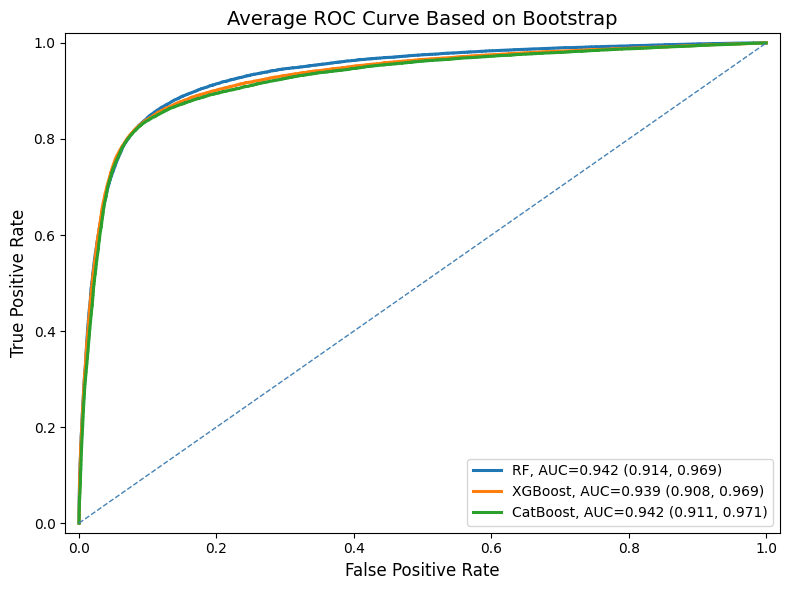

In [85]:
# Bootstrap ROC 曲線
plot_bootstrap_roc(bootstrap_data)

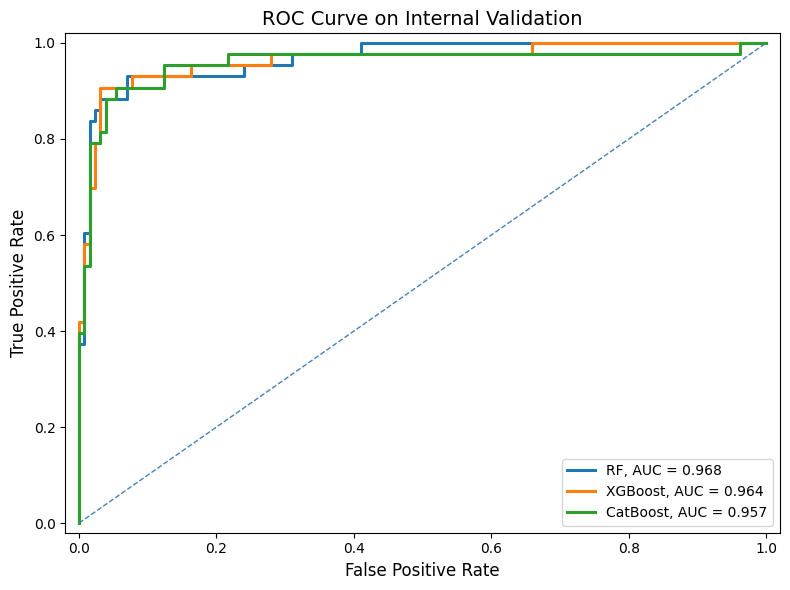

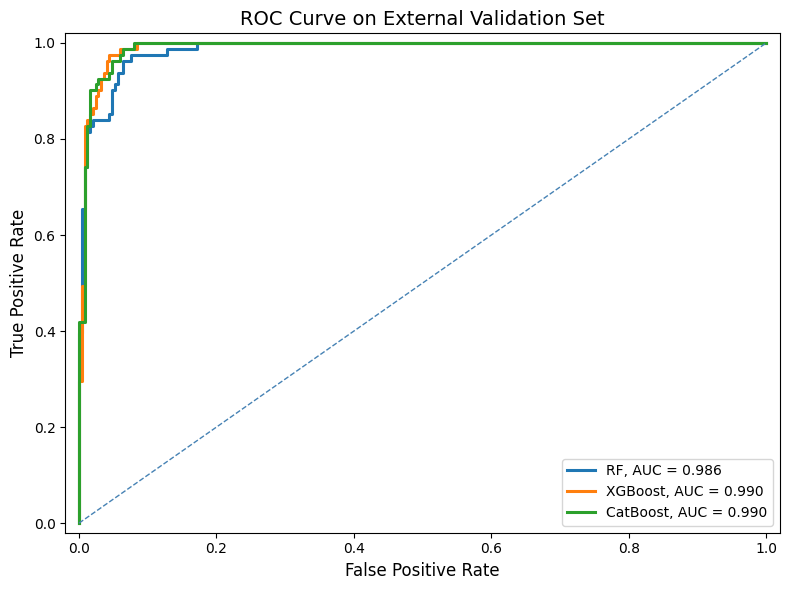

In [87]:
#Internal／External ROC
def plot_validation_roc(model_data, title):
    # 保存各模型的 AUC
    auc_results = {}
    # 建立 ROC 圖表
    plt.figure(figsize=(8, 6))
    # 分別計算並繪製各模型的 ROC 曲線
    for model_name, predictions in model_data.items():
        # 取得真實標籤及模型預測機率
        y_true = predictions["y_true"].to_numpy()
        y_prob = predictions["y_prob"].to_numpy()
        # 計算 ROC 曲線座標及 AUC
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)
        # 保存各模型的 AUC
        auc_results[model_name] = auc_value
        # 繪製 ROC 曲線，並在圖例中顯示 AUC
        plt.plot(fpr, tpr, linewidth=2.2, label=f"{model_name}, AUC = {auc_value:.3f}")

    plt.plot([0, 1], [0, 1], "--", color="steelblue", linewidth=1)
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()

    return auc_results

internal_auc = plot_validation_roc(internal_data, "ROC Curve on Internal Validation")
external_auc = plot_validation_roc(external_data, "ROC Curve on External Validation Set")

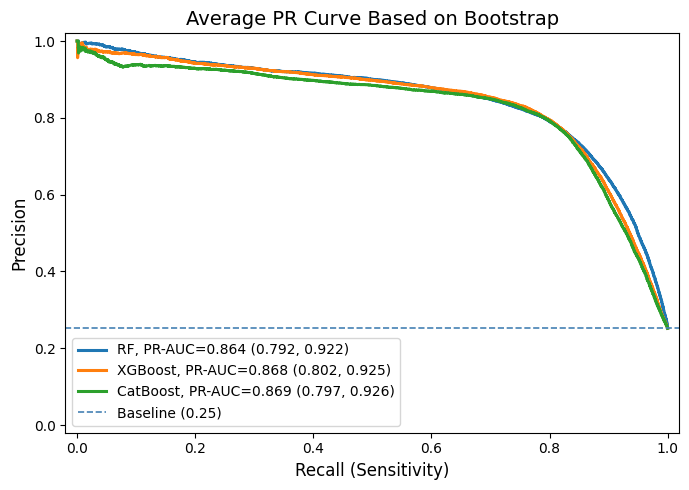

In [89]:
# Bootstrap PR curve
def plot_bootstrap_pr(bootstrap_data, title="Average PR Curve Based on Bootstrap"):
    # 建立 PR 曲線
    plt.figure(figsize=(7, 5))
    # 分別計算並繪製各模型的 PR 曲線
    for model_name, data in bootstrap_data.items():
        # 使用彙整後的 OOB 預測結果計算 Precision–Recall 曲線
        precision, recall, _ = precision_recall_curve(data["y_true"], data["y_prob"])
        # 計算各輪 Bootstrap PR-AUC 的平均值與 95% 信賴區間
        aucpr_ci = ci(data["results"]["aucpr"])
        # 設定圖例中顯示的模型名稱、平均 PR-AUC 及信賴區間
        label = f"{model_name}, PR-AUC={aucpr_ci['mean']:.3f} ({aucpr_ci['lower']:.3f}, {aucpr_ci['upper']:.3f})"
        plt.plot(recall, precision, linewidth=2.2, label=label)
    # 使用資料中的正類別比例作為 PR 曲線的基準線
    first_data = next(iter(bootstrap_data.values()))
    prevalence = np.mean(first_data["y_true"])
    plt.axhline(prevalence, color="steelblue", linestyle="--", linewidth=1.2, label=f"Baseline ({prevalence:.2f})")

    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Recall (Sensitivity)", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower left", fontsize=10)
    plt.tight_layout()
    plt.show()

plot_bootstrap_pr(bootstrap_data)

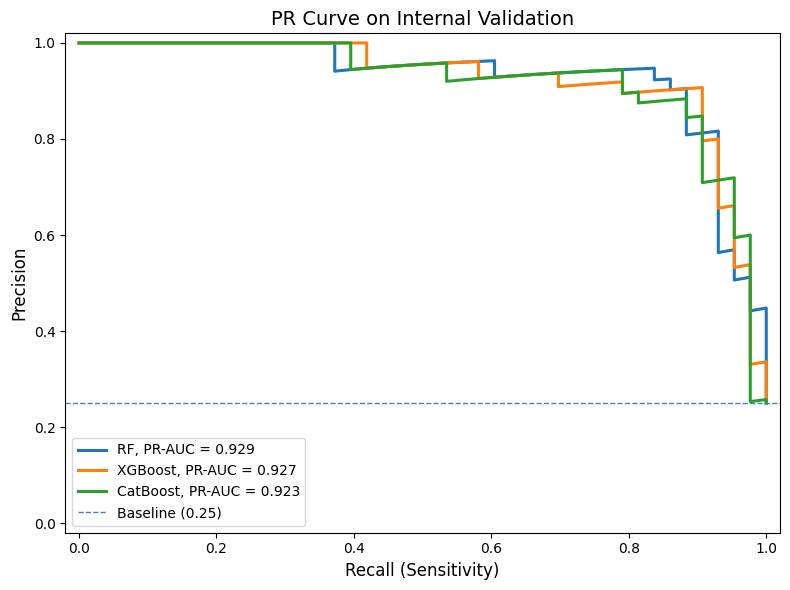

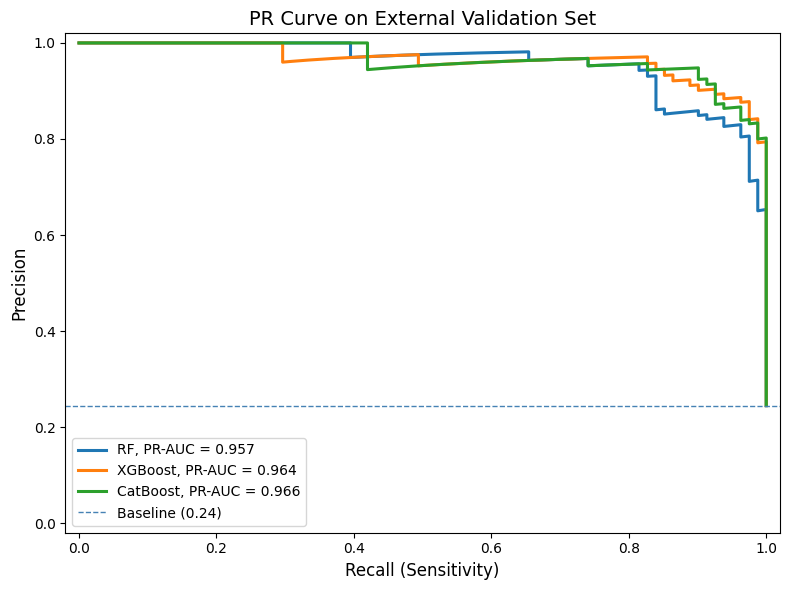

In [90]:
#Internal／External PR curve
def plot_validation_pr(model_data, title):
    ap_results = {}
    plt.figure(figsize=(8, 6))

    first_predictions = next(iter(model_data.values()))
    prevalence = np.mean(first_predictions["y_true"])

    for model_name, predictions in model_data.items():
        y_true = predictions["y_true"].to_numpy()
        y_prob = predictions["y_prob"].to_numpy()
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        ap_results[model_name] = ap
        plt.plot(recall, precision, linewidth=2.2, label=f"{model_name}, PR-AUC = {ap:.3f}")
    # 使用正類別比例作為 PR 曲線的基準線
    plt.axhline(prevalence, color="steelblue", linestyle="--", linewidth=1, label=f"Baseline ({prevalence:.2f})")
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Recall (Sensitivity)", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower left", fontsize=10)
    plt.tight_layout()
    plt.show()

    return ap_results

internal_ap = plot_validation_pr(internal_data, "PR Curve on Internal Validation")
external_ap = plot_validation_pr(external_data, "PR Curve on External Validation Set")

# Calibration Curve

In [48]:
# RF 在內部測試集及外部驗證集上的預測結果
rf_y_pred_test_prob = rf_final_output["internal_predictions"]["y_prob"].to_numpy()
rf_y_pred_test_label = rf_final_output["internal_predictions"]["y_pred"].to_numpy()
external_prob_rf = rf_final_output["external_predictions"]["y_prob"].to_numpy()
external_pred_rf = rf_final_output["external_predictions"]["y_pred"].to_numpy()

# XGBoost 在內部測試集及外部驗證集上的預測結果
xgb_y_pred_test_prob = xgb_final_output["internal_predictions"]["y_prob"].to_numpy()
xgb_y_pred_test_label = xgb_final_output["internal_predictions"]["y_pred"].to_numpy()
external_prob = xgb_final_output["external_predictions"]["y_prob"].to_numpy()
external_pred = xgb_final_output["external_predictions"]["y_pred"].to_numpy()

# CatBoost 在內部測試集及外部驗證集上的預測結果
cat_y_pred_test_prob = cat_final_output["internal_predictions"]["y_prob"].to_numpy()
cat_y_pred_test_label = cat_final_output["internal_predictions"]["y_pred"].to_numpy()
external_prob_cat = cat_final_output["external_predictions"]["y_prob"].to_numpy()
external_pred_cat = cat_final_output["external_predictions"]["y_pred"].to_numpy()

print("三個模型的 Internal／External 預測變數已建立")

三個模型的 Internal／External 預測變數已建立


In [49]:
# 載入套件與共用資料
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# 整理三個模型的 Bootstrap OOB 真實標籤與預測機率
train_calibration_data = {
    "RF": (np.asarray(all_y_true), np.asarray(all_y_prob)),
    "XGBoost": (np.asarray(xgb_all_y_true), np.asarray(xgb_all_y_prob)),
    "CatBoost": (np.asarray(cat_all_y_true), np.asarray(cat_all_y_prob)),
}

# Internal validation 真實標籤與預測機率
internal_calibration_data = {
    "RF": (np.asarray(y_test30), np.asarray(rf_y_pred_test_prob)),
    "XGBoost": (np.asarray(y_test30), np.asarray(xgb_y_pred_test_prob)),
    "CatBoost": (np.asarray(y_test30), np.asarray(cat_y_pred_test_prob)),
}

# External validation 真實標籤與預測機率
external_calibration_data = {
    "RF": (np.asarray(y_external), np.asarray(external_prob_rf)),
    "XGBoost": (np.asarray(y_external), np.asarray(external_prob)),
    "CatBoost": (np.asarray(y_external), np.asarray(external_prob_cat)),
}

In [50]:
# 校準圖函式
def plot_calibration_curves(model_data, title, n_bins=10, strategy="quantile"):
    # 設定各模型在圖中的標記形狀與顏色
    styles = {
        "RF": {"marker": "s", "color": "C0"},
        "XGBoost": {"marker": "o", "color": "C1"},
        "CatBoost": {"marker": "^", "color": "C2"},
    }
    # 建立圖表並加對角參考線
    plt.figure(figsize=(8, 7))
    plt.plot([0, 1], [0, 1], "--", color="steelblue", linewidth=1, label="Perfect calibration")
    # 保存各模型的校準曲線資料
    calibration_results = {}
    # 分別計算並繪製各模型的校準曲線
    for model_name, (y_true, y_prob) in model_data.items():
        # 將樣本分組，計算各組的平均預測機率與實際發生比例
        p_true, p_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy=strategy)
        style = styles[model_name]
        # 繪製該模型的校準曲線
        plt.plot(p_pred, p_true, marker=style["marker"], color=style["color"], linewidth=2.2, label=model_name)
        # 保存校準曲線座標
        calibration_results[model_name] = {"p_true": p_true, "p_pred": p_pred}

    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Predicted Probability", fontsize=16, labelpad=15)
    plt.ylabel("Actual Probability", fontsize=16, labelpad=15)
    plt.title(title, fontsize=20, pad=20, fontweight="bold")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(loc="upper left", fontsize=14, frameon=True)
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

    return calibration_results

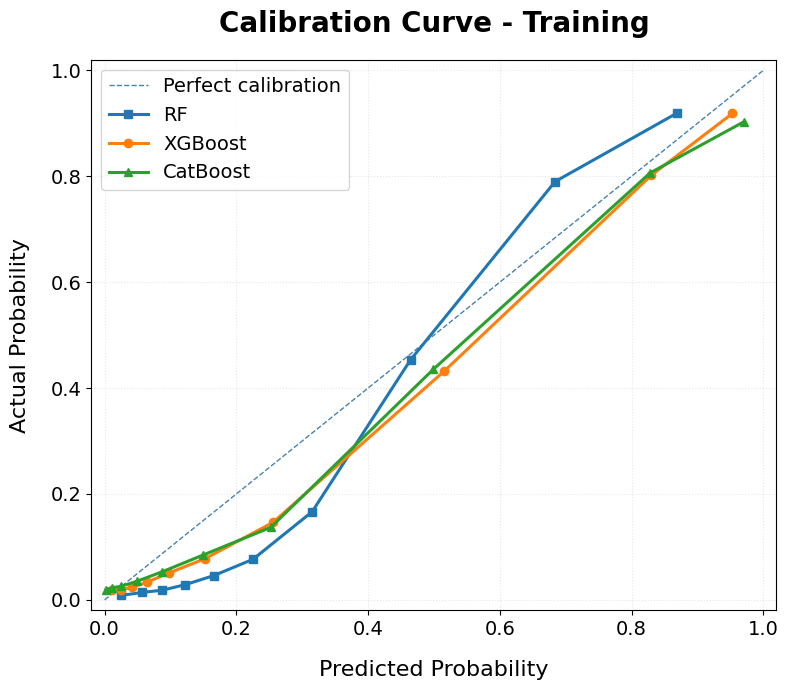

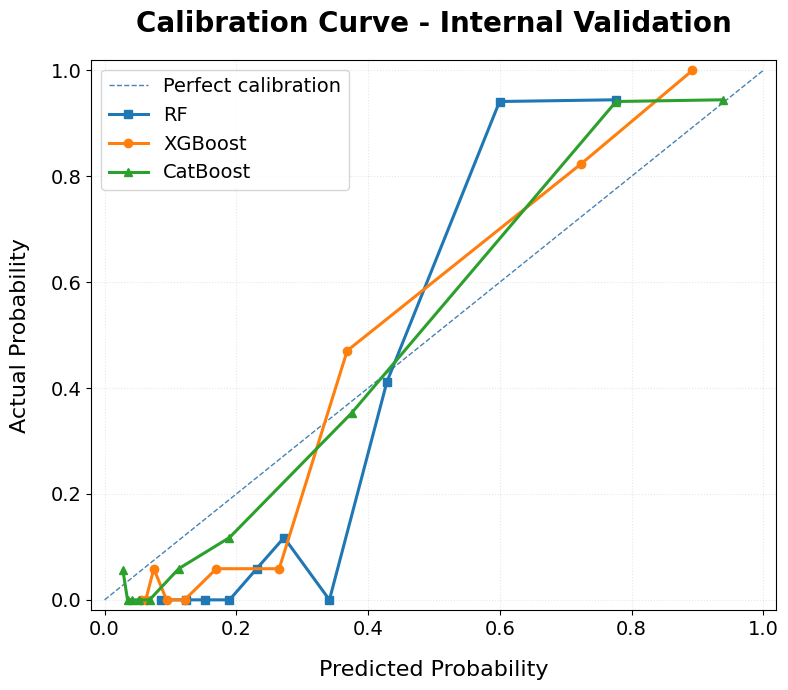

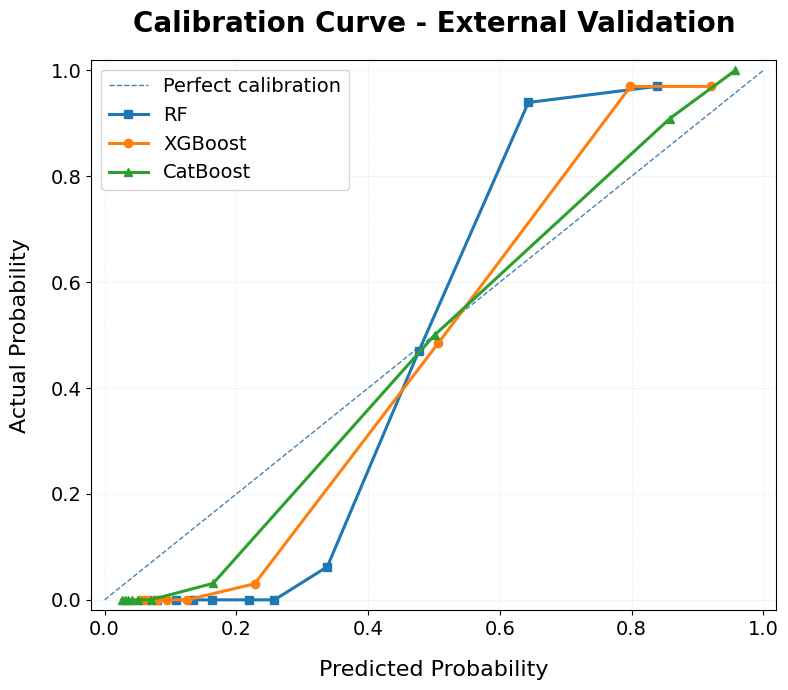

In [51]:
# 繪製 Bootstrap OOB 預測的校準曲線
train_calibration_results = plot_calibration_curves(
    train_calibration_data,
    title="Calibration Curve - Training",
    n_bins=10,
    strategy="quantile",
)
# 內部測試集
internal_calibration_results = plot_calibration_curves(
    internal_calibration_data,
    title="Calibration Curve - Internal Validation",
    n_bins=10,
    strategy="quantile",
)
# 外部驗證集
external_calibration_results = plot_calibration_curves(
    external_calibration_data,
    title="Calibration Curve - External Validation",
    n_bins=10,
    strategy="quantile",
)

In [52]:
#Brier Score 函式
def calculate_brier_scores(model_data, dataset_name):
    # 根據真實標籤與預測機率，計算各模型的 Brier Score
    scores = {
        model_name: brier_score_loss(y_true, y_prob)
        for model_name, (y_true, y_prob) in model_data.items()
    }
    # 顯示各模型的 Brier Score
    print(f"Brier Scores for {dataset_name} (Lower is better):")
    print(f"RF:       {scores['RF']:.4f}")
    print(f"XGBoost:  {scores['XGBoost']:.4f}")
    print(f"CatBoost: {scores['CatBoost']:.4f}")

    return scores

In [53]:
# 計算 Bootstrap OOB 預測的 Brier Score
train_brier_scores = calculate_brier_scores(train_calibration_data, "Training")
# 內部測試集
internal_brier_scores = calculate_brier_scores(internal_calibration_data, "Internal Validation")
# 外部驗證集
external_brier_scores = calculate_brier_scores(external_calibration_data, "External Validation")

Brier Scores for Training (Lower is better):
RF:       0.0879
XGBoost:  0.0821
CatBoost: 0.0838
Brier Scores for Internal Validation (Lower is better):
RF:       0.0879
XGBoost:  0.0649
CatBoost: 0.0575
Brier Scores for External Validation (Lower is better):
RF:       0.0742
XGBoost:  0.0425
CatBoost: 0.0354


In [54]:
#Training OOB 的 HL 與 ACE
def hosmer_lemeshow_test_quantile(y_true, y_prob, groups=10, eps=1e-12):
    # 真實標籤與預測機率轉換為一維 NumPy 陣列
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
   # 移除真實標籤或預測機率中的無效值
    mask = np.isfinite(y_prob) & np.isfinite(y_true)
    y_true, y_prob = y_true[mask], y_prob[mask]
    # 若沒有可用資料，回傳無法計算的結果
    if y_true.size == 0:
        return np.nan, 0, np.nan, 0
    # 依照預測機率的分位數建立分組邊界
    edges = np.unique(np.quantile(y_prob, np.linspace(0, 1, groups + 1)))
    # 若預測機率變化太少而無法形成至少兩組，則不進行檢定
    if edges.size < 3:
        return np.nan, 0, np.nan, int(edges.size - 1)
    # 將最小及最大邊界延伸，確保所有樣本均被納入分組
    edges[0], edges[-1] = -np.inf, np.inf
    # 根據預測機率將樣本分配至各組
    bin_id = np.digitize(y_prob, edges[1:-1], right=True)
    effective_groups = int(bin_id.max() + 1)
    # 比較各組正類別與負類別的觀察值及期望值
    hl_stat = 0.0
    for group in range(effective_groups):
        group_mask = bin_id == group
        n = int(group_mask.sum())
        if n == 0:
            continue
        # 計算該組正類別的觀察數與預期數
        observed_1 = float(y_true[group_mask].sum())
        expected_1 = float(y_prob[group_mask].sum())
        # 計算該組負類別的觀察數與預期數
        observed_0 = n - observed_1
        expected_0 = n - expected_1
        # 累加正、負類別對 HL 統計量的貢獻
        hl_stat += (observed_1 - expected_1) ** 2 / (expected_1 + eps)
        hl_stat += (observed_0 - expected_0) ** 2 / (expected_0 + eps)
    # 計算自由度與 p 值
    dof = max(effective_groups - 2, 0)
    p_value = 1.0 - chi2.cdf(hl_stat, dof) if dof > 0 else np.nan
    return float(hl_stat), int(dof), float(p_value), int(effective_groups)

In [55]:
# 彙整同一樣本在不同 Bootstrap 輪次中的 OOB 預測
def aggregate_oob_predictions(y_true, y_prob, sample_id, agg="mean"):
    # 整理樣本索引、真實標籤及 OOB 預測機率
    df = pd.DataFrame({
        "id": np.asarray(sample_id).ravel(),
        "y": np.asarray(y_true).ravel(),
        "p": np.asarray(y_prob).ravel(),
    })
    # 移除真實標籤或預測機率中的無效值
    df = df[np.isfinite(df["p"]) & np.isfinite(df["y"])]
    
    # 以平均值彙整同一樣本的多次 OOB 預測
    if agg == "mean":
        return df.groupby("id").agg(y=("y", "first"), p=("p", "mean")).reset_index()
    # 以中位數彙整同一樣本的多次 OOB 預測
    if agg == "median":
        return df.groupby("id").agg(y=("y", "first"), p=("p", "median")).reset_index()

    raise ValueError("agg must be 'mean' or 'median'")

In [56]:
# 計算適應性校準誤差（ACE）
def calculate_ace(y_true, y_prob, n_bins=5):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    order = np.argsort(y_prob)
    y_true_sorted, y_prob_sorted = y_true[order], y_prob[order]
    groups = np.array_split(np.arange(len(y_true)), n_bins)

    return np.mean([
        np.abs(np.mean(y_prob_sorted[group]) - np.mean(y_true_sorted[group]))
        for group in groups
    ])

In [57]:
#計算彙整後 OOB 預測的 HL 檢定與 ACE
def get_oob_metrics(y_true, y_prob, sample_id, groups=5):
    aggregated = aggregate_oob_predictions(y_true, y_prob, sample_id, agg="mean")

    hl_stat, dof, p_value, effective_groups = hosmer_lemeshow_test_quantile(
        aggregated["y"], aggregated["p"], groups=groups
    )

    ace = calculate_ace(aggregated["y"], aggregated["p"], n_bins=groups)

    return {
        "HL-stat": hl_stat,
        "dof": dof,
        "p-value": p_value,
        "ACE": ace,
        "effective_groups": effective_groups,
        "n_unique": len(aggregated),
    }

In [58]:
# 整理三個模型的 OOB 真實標籤、預測機率及樣本索引
oob_data = {
    "Random Forest": (all_y_true, all_y_prob, rf_all_y_id),
    "XGBoost": (xgb_all_y_true, xgb_all_y_prob, xgb_all_y_id),
    "CatBoost": (cat_all_y_true, cat_all_y_prob, cat_all_y_id),
}

In [59]:
N_GROUPS = 10
# 計算三個模型的 OOB 校準指標
training_oob_metrics = {
    model_name: get_oob_metrics(y_true, y_prob, sample_id, groups=N_GROUPS)
    for model_name, (y_true, y_prob, sample_id) in oob_data.items()
}

print(f"Training (OOB Aggregated with ID, Groups={N_GROUPS})")
print(f"{'Model':<15} | {'HL-stat':<10} | {'p-value':<10} | {'ACE':<10}")
print("-" * 60)

for model_name, result in training_oob_metrics.items():
    print(
        f"{model_name:<15} | "
        f"{result['HL-stat']:<10.4f} | "
        f"{result['p-value']:<10.4f} | "
        f"{result['ACE']:<10.4f}"
    )

Training (OOB Aggregated with ID, Groups=10)
Model           | HL-stat    | p-value    | ACE       
------------------------------------------------------------
Random Forest   | 32.2928    | 0.0001     | 0.0971    
XGBoost         | 11.9407    | 0.1539     | 0.0471    
CatBoost        | 11.1458    | 0.1936     | 0.0414    


In [61]:
# Internal／External HL 檢定
def hosmer_lemeshow_test(y_true, y_prob, groups=10, strategy="uniform"):
    # 將真實標籤與預測機率轉換為一維陣列
    y_true = np.asarray(y_true).flatten()
    y_prob = np.asarray(y_prob).flatten()
    # 根據指定策略建立預測機率的分組邊界
    if strategy == "quantile":
        # 依分位數分組
        edges = np.unique(np.quantile(y_prob, np.linspace(0, 1, groups + 1)))
    else:
        # 將 0 至 1 的預測機率範圍等距分組
        edges = np.linspace(0, 1, groups + 1)
    # 延伸首尾邊界，確保所有樣本均能被納入分組
    edges[0], edges[-1] = -np.inf, np.inf
    # 根據預測機率將樣本分配至各組
    bin_ids = np.digitize(y_prob, edges[1:-1], right=True)
     # 初始化 HL 統計量及實際有效分組數
    hl_stat, actual_groups = 0.0, 0
    # 逐組比較實際結果與模型預期結果
    for group in range(groups):
        mask = bin_ids == group
        n = np.sum(mask)
        # 略過沒有樣本的分組
        if n == 0:
            continue

        actual_groups += 1
        # 計算該組正類別的觀察數與預期數
        observed_1 = np.sum(y_true[mask])
        expected_1 = np.sum(y_prob[mask])
        # 計算該組負類別的觀察數與預期數
        observed_0 = n - observed_1
        expected_0 = n - expected_1
        # 累加正、負類別對 HL 統計量的貢獻
        hl_stat += (observed_1 - expected_1) ** 2 / (expected_1 + 1e-12)
        hl_stat += (observed_0 - expected_0) ** 2 / (expected_0 + 1e-12)

    dof = max(actual_groups - 2, 1)
    p_value = 1 - chi2.cdf(hl_stat, dof)
    return hl_stat, p_value

In [62]:
# 比較三個模型在指定資料集上的 HL 檢定結果
def compare_hl_tests(model_data, dataset_name, groups=10, strategy="quantile"):
    results = {}

    print(f"{dataset_name} (Groups={groups})")
    for model_name, (y_true, y_prob) in model_data.items():
        hl_stat, p_value = hosmer_lemeshow_test(
            y_true, y_prob, groups=groups, strategy=strategy
        )

        results[model_name] = {"HL-stat": hl_stat, "p-value": p_value}
        print(f"{model_name:<14}: HL-stat = {hl_stat:.4f}, p-value = {p_value:.4f}")

    return results

In [63]:
N_BINS = 10
# 比較三個模型在內部測試集上的 HL 檢定結果
internal_hl_results = compare_hl_tests(
    internal_calibration_data,
    dataset_name="Internal Validation",
    groups=N_BINS,
    strategy="quantile",
)

print("-" * 50)
# 比較三個模型在外部驗證集上的 HL 檢定結果
external_hl_results = compare_hl_tests(
    external_calibration_data,
    dataset_name="External Validation",
    groups=N_BINS,
    strategy="quantile",
)

Internal Validation (Groups=10)
RF            : HL-stat = 36.0316, p-value = 0.0000
XGBoost       : HL-stat = 15.3447, p-value = 0.0528
CatBoost      : HL-stat = 7.7925, p-value = 0.4540
--------------------------------------------------
External Validation (Groups=10)
RF            : HL-stat = 67.4658, p-value = 0.0000
XGBoost       : HL-stat = 31.9136, p-value = 0.0001
CatBoost      : HL-stat = 15.5192, p-value = 0.0498


# Decision Curve

In [64]:
# 匯入繪製 DCA 圖所需套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 在不同機率閾值下計算模型的淨效益
def calculate_net_benefit(y_true, y_prob, thresholds, eps=1e-12):
    # 將真實標籤、預測機率及閾值轉換為 NumPy 陣列
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob).astype(float).ravel()
    thresholds = np.asarray(thresholds, dtype=float)
    # 取得樣本數，並建立儲存各閾值淨效益的陣列
    n = len(y_true)
    net_benefits = np.empty(len(thresholds), dtype=float)
   # 逐一計算各機率閾值下的真陽性、假陽性及淨效益
    for i, threshold in enumerate(thresholds):
        tp = np.sum((y_prob >= threshold) & (y_true == 1))
        fp = np.sum((y_prob >= threshold) & (y_true == 0))
        denominator = max(1.0 - threshold, eps)
        net_benefits[i] = (tp / n) - (fp / n) * (threshold / denominator)

    return net_benefits

In [68]:
import numpy as np

# Training pooled OOB：RF
rf_true_flat = np.asarray(rf_output["all_y_true"])
rf_prob_flat = np.asarray(rf_output["all_y_prob"])
rf_all_y_id = np.asarray(rf_output["all_y_id"])

# Training pooled OOB：XGBoost
xgb_true_flat = np.asarray(xgb_output["all_y_true"])
xgb_prob_flat = np.asarray(xgb_output["all_y_prob"])
xgb_all_y_id = np.asarray(xgb_output["all_y_id"])

# Training pooled OOB：CatBoost
cat_true_flat = np.asarray(cat_output["all_y_true"])
cat_prob_flat = np.asarray(cat_output["all_y_prob"])
cat_all_y_id = np.asarray(cat_output["all_y_id"])

print("Training pooled OOB 變數已建立")
print("RF:", len(rf_true_flat), len(rf_prob_flat))
print("XGBoost:", len(xgb_true_flat), len(xgb_prob_flat))
print("CatBoost:", len(cat_true_flat), len(cat_prob_flat))

Training pooled OOB 變數已建立
RF: 99328 99328
XGBoost: 99328 99328
CatBoost: 99328 99328


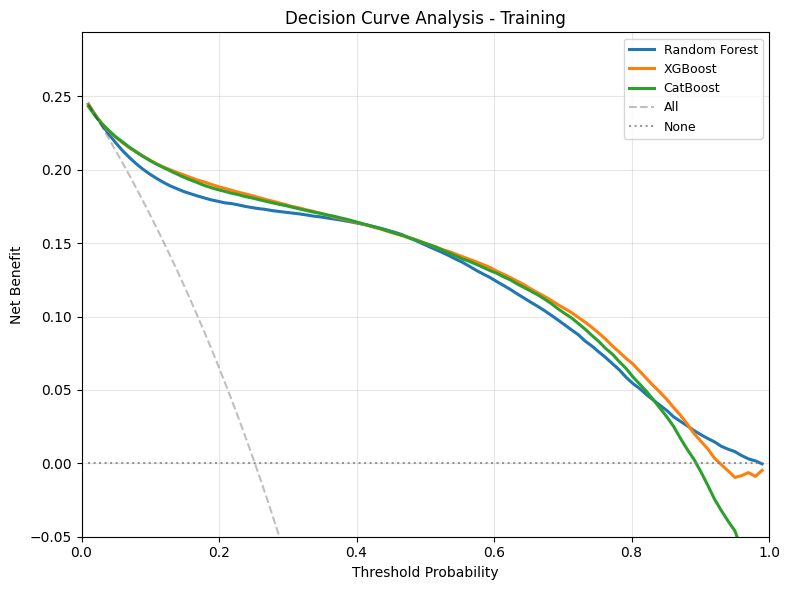

In [71]:
# Training DCA 圖
def plot_training_dca(rf_true, rf_prob, xgb_true, xgb_prob, cat_true, cat_prob, title, thresholds=None):
    # 若未指定閾值，建立 0.01 至 0.99 的機率閾值
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)
    # 計算三個模型在各閾值下的淨效益
    rf_nb = calculate_net_benefit(rf_true, rf_prob, thresholds)
    xgb_nb = calculate_net_benefit(xgb_true, xgb_prob, thresholds)
    cat_nb = calculate_net_benefit(cat_true, cat_prob, thresholds)
    # 計算將所有樣本皆判定為正類別時的淨效益
    rf_all = calculate_net_benefit(rf_true, np.ones(len(rf_true)), thresholds)
    xgb_all = calculate_net_benefit(xgb_true, np.ones(len(xgb_true)), thresholds)
    cat_all = calculate_net_benefit(cat_true, np.ones(len(cat_true)), thresholds)
    # 繪製三個模型的淨效益曲線
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, rf_nb, color="C0", lw=2.2, label="Random Forest")
    plt.plot(thresholds, xgb_nb, color="C1", lw=2.2, label="XGBoost")
    plt.plot(thresholds, cat_nb, color="C2", lw=2.2, label="CatBoost")
    plt.plot(thresholds, rf_all, color="black", linestyle="--", alpha=0.25, label="All")
    plt.plot(thresholds, np.zeros_like(thresholds), color="gray", linestyle=":", alpha=0.8, label="None")
    # 根據所有曲線的最大值設定縱軸範圍
    y_max = np.nanmax([rf_nb.max(), xgb_nb.max(), cat_nb.max(), rf_all.max(), xgb_all.max(), cat_all.max()])
    plt.ylim(-0.05, y_max * 1.2)
    plt.xlim(0, 1)
    plt.xlabel("Threshold Probability")
    plt.ylabel("Net Benefit")
    plt.title(title)
    plt.legend(loc="upper right", fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {"RF": rf_nb, "XGBoost": xgb_nb, "CatBoost": cat_nb, "All": rf_all}

# 繪製三個模型在 Bootstrap OOB 資料上的 DCA 圖
training_dca_curves = plot_training_dca(
    rf_true_flat, rf_prob_flat,
    xgb_true_flat, xgb_prob_flat,
    cat_true_flat, cat_prob_flat,
    title="Decision Curve Analysis - Training",
)

In [72]:
# Internal／External DCA 圖
def plot_validation_dca(y_true, rf_prob, xgb_prob, cat_prob, title, thresholds=None):
    # 若未指定閾值，建立 0.01 至 0.99 的機率閾值
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)

    y_true = np.asarray(y_true).astype(int).ravel()
    rf_nb = calculate_net_benefit(y_true, rf_prob, thresholds)
    xgb_nb = calculate_net_benefit(y_true, xgb_prob, thresholds)
    cat_nb = calculate_net_benefit(y_true, cat_prob, thresholds)
    all_nb = calculate_net_benefit(y_true, np.ones(len(y_true)), thresholds)

    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, rf_nb, color="C0", lw=2.2, label="Random Forest")
    plt.plot(thresholds, xgb_nb, color="C1", lw=2.2, label="XGBoost")
    plt.plot(thresholds, cat_nb, color="C2", lw=2.2, label="CatBoost")
    plt.plot(thresholds, all_nb, color="black", linestyle="--", alpha=0.5, label="All")
    plt.plot(thresholds, np.zeros_like(thresholds), color="gray", linestyle=":", alpha=0.8, label="None")

    y_max = max(rf_nb.max(), xgb_nb.max(), cat_nb.max(), all_nb.max())
    plt.ylim(-0.05, y_max * 1.2)
    plt.xlim(0, 1.0)
    plt.xlabel("Threshold Probability", fontsize=12)
    plt.ylabel("Net Benefit", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {"RF": rf_nb, "XGBoost": xgb_nb, "CatBoost": cat_nb, "All": all_nb}

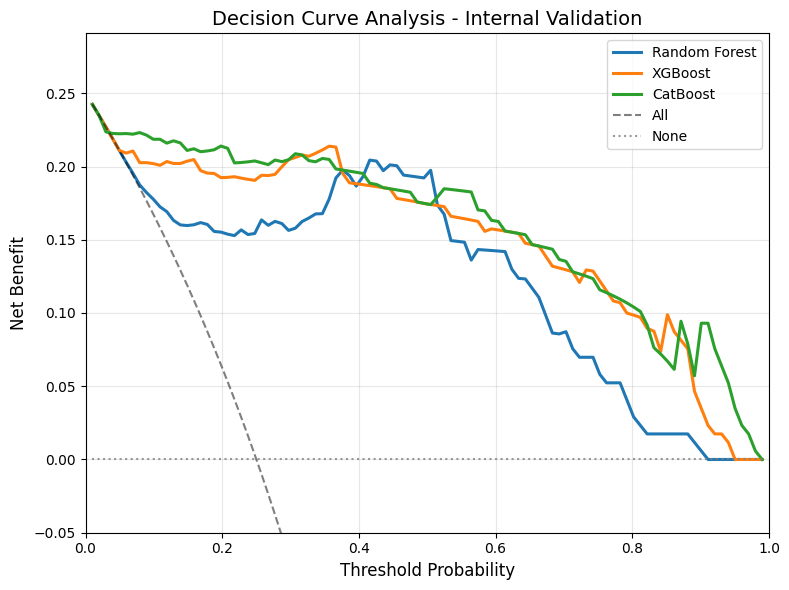

In [73]:
internal_dca_curves = plot_validation_dca(
    y_true=y_test30,
    rf_prob=rf_y_pred_test_prob,
    xgb_prob=xgb_y_pred_test_prob,
    cat_prob=cat_y_pred_test_prob,
    title="Decision Curve Analysis - Internal Validation",
)

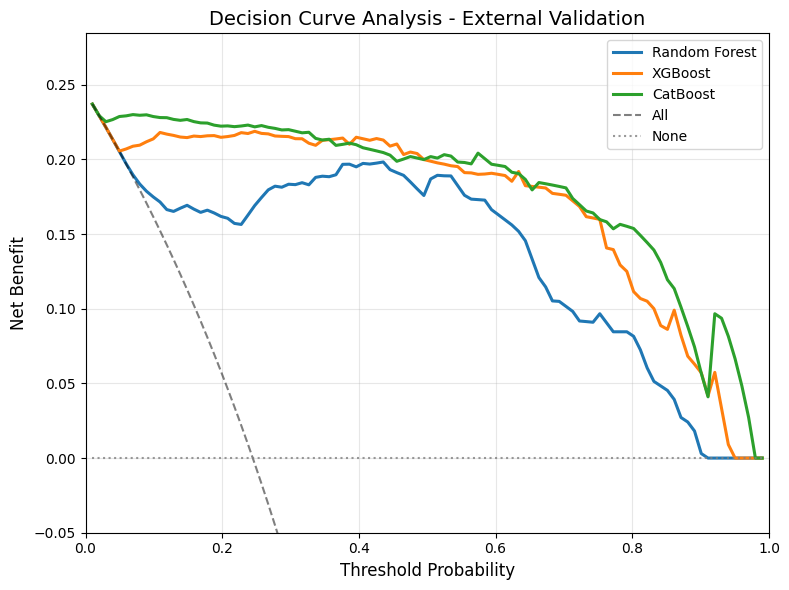

In [74]:
external_dca_curves = plot_validation_dca(
    y_true=y_external,
    rf_prob=external_prob_rf,
    xgb_prob=external_prob,
    cat_prob=external_prob_cat,
    title="Decision Curve Analysis - External Validation",
)

In [77]:
# DCA 曲線下面積
def dca_auc(y_true, y_prob, thresholds=None, t_min=None, t_max=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)

    thresholds = np.asarray(thresholds, dtype=float)
    net_benefit = calculate_net_benefit(y_true, y_prob, thresholds)

    mask = np.ones_like(thresholds, dtype=bool)
    if t_min is not None:
        mask &= thresholds >= t_min
    if t_max is not None:
        mask &= thresholds <= t_max

    return np.trapezoid(net_benefit[mask], thresholds[mask])
# 計算並整理多個模型的 DCA 曲線下面積
def calculate_dca_auc_table(model_data, dataset_name, thresholds=None, t_min=None, t_max=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)

    results = {
        model_name: dca_auc(y_true, y_prob, thresholds, t_min, t_max)
        for model_name, (y_true, y_prob) in model_data.items()
    }

    result_df = pd.DataFrame({
        "Dataset": dataset_name,
        "Model": list(results.keys()),
        "DCA_AUC": list(results.values()),
    })

    print(f"{dataset_name} AUC (DCA)")
    for model_name, area in results.items():
        print(f"{model_name:<14}: {area:.6f}")

    return results, result_df

In [79]:
# Training AUNB
thresholds = np.linspace(0.01, 0.99, 100)

rf_area = dca_auc(
    rf_true_flat,
    rf_prob_flat,
    thresholds,
)

xgb_area = dca_auc(
    rf_true_flat,
    xgb_prob_flat,
    thresholds,
)

cat_area = dca_auc(
    rf_true_flat,
    cat_prob_flat,
    thresholds,
)

print("AUNB (0.01~0.99)")
print("RF :", rf_area)
print("XGB:", xgb_area)
print("CAT:", cat_area)

AUNB (0.01~0.99)
RF : 0.12502301927668563
XGB: 0.12967780023293507
CAT: 0.1229654710445238


In [80]:
#Internal AUNB
internal_auc_data = {
    "RF": (y_test30, rf_y_pred_test_prob),
    "XGBoost": (y_test30, xgb_y_pred_test_prob),
    "CatBoost": (y_test30, cat_y_pred_test_prob),
    "All": (y_test30, np.ones(len(y_test30))),
}

internal_dca_auc, internal_dca_auc_df = calculate_dca_auc_table(
    model_data=internal_auc_data,
    dataset_name="Internal Validation",
    thresholds=thresholds,
)

rf_auc_int = internal_dca_auc["RF"]
xgb_auc_int = internal_dca_auc["XGBoost"]
cat_auc_int = internal_dca_auc["CatBoost"]
all_auc_int = internal_dca_auc["All"]

Internal Validation AUC (DCA)
RF            : 0.122959
XGBoost       : 0.149329
CatBoost      : 0.157484
All           : -2.523152


In [81]:
# External AUNB
external_auc_data = {
    "RF": (y_external, external_prob_rf),
    "XGBoost": (y_external, external_prob),
    "CatBoost": (y_external, external_prob_cat),
    "All": (y_external, np.ones(len(y_external))),
}

external_dca_auc, external_dca_auc_df = calculate_dca_auc_table(
    model_data=external_auc_data,
    dataset_name="External Validation",
    thresholds=thresholds,
)

rf_auc_ext = external_dca_auc["RF"]
xgb_auc_ext = external_dca_auc["XGBoost"]
cat_auc_ext = external_dca_auc["CatBoost"]
all_auc_ext = external_dca_auc["All"]

External Validation AUC (DCA)
RF            : 0.134855
XGBoost       : 0.168253
CatBoost      : 0.178723
All           : -2.547847


# 保存所有 SHAP 輸入

In [98]:
import os
import joblib

output_folder = "Model_1_Results_include"
os.makedirs(output_folder, exist_ok=True)

shap_bundle = {
    # 三個最終模型
    "rf_model": rf_final_output["model"],
    "xgb_model": xgb_final_output["model"],
    "cat_model": cat_final_output["model"],

    # SHAP 特徵資料
    "X_train": X_train70[feature_order].copy(),
    "X_train_smotenc": pd.DataFrame(
        X_train_resampled,
        columns=feature_order,
    ),
    "X_internal": X_test30[feature_order].copy(),
    "X_external": X_external[feature_order].copy(),

    # 標籤
    "y_train": np.asarray(y_train70),
    "y_train_smotenc": np.asarray(y_train_resampled),
    "y_internal": np.asarray(y_test30),
    "y_external": np.asarray(y_external),

    # 特徵設定
    "feature_order": feature_order,
    "continuous_cols": continuous_cols,
    "categorical_indices": categorical_indices,
    "random_seed": 42,
}

bundle_path = os.path.join(
    output_folder,
    "SHAP_Complete_Bundle.pkl",
)

joblib.dump(
    shap_bundle,
    bundle_path,
    compress=3,
)

print("SHAP 模型與資料已保存：")
print(os.path.abspath(bundle_path))

SHAP 模型與資料已保存：
/home/claire901114/碩論_口腔癌/模型一/Model_1_Results_include/SHAP_Complete_Bundle.pkl
